# S&P 500 (^GSPC) Exploratory Data Analysis

---



In [1]:
!pip install yfinance --quiet

## Imports & Configuration

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis, norm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)

TICKER = "^GSPC"
START  = "1993-01-01"
END    = "2026-01-01"

## Data Download & Initial Inspection

In [3]:
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)

# Flatten MultiIndex columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

data = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
data.index = pd.to_datetime(data.index)
data.index.name = "Date"

print(f"Ticker  : {TICKER}")
print(f"Period  : {data.index[0].date()} → {data.index[-1].date()}")
print(f"Shape   : {data.shape}\n")
print(data.head())
print("\n", data.tail())
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())

[*********************100%***********************]  1 of 1 completed

Ticker  : ^GSPC
Period  : 1993-01-04 → 2025-12-31
Shape   : (8307, 5)

Price            Open       High        Low      Close     Volume
Date                                                             
1993-01-04 435.700012 437.320007 434.480011 435.380005  201210000
1993-01-05 435.380005 435.399994 433.549988 434.339996  240350000
1993-01-06 434.339996 435.170013 432.519989 434.519989  295240000
1993-01-07 434.519989 435.459991 429.760010 430.730011  304850000
1993-01-08 430.730011 430.730011 426.880005 429.049988  263470000

 Price             Open        High         Low       Close      Volume
Date                                                                  
2025-12-24 6904.910156 6937.319824 6904.910156 6932.049805  1798270000
2025-12-26 6936.020020 6945.770020 6921.600098 6929.939941  2586550000
2025-12-29 6903.600098 6920.209961 6888.759766 6905.740234  3541750000
2025-12-30 6900.439941 6913.250000 6893.470215 6896.240234  3309930000
2025-12-31 6898.819824 6901.419922 6844

## Price Series & Volume

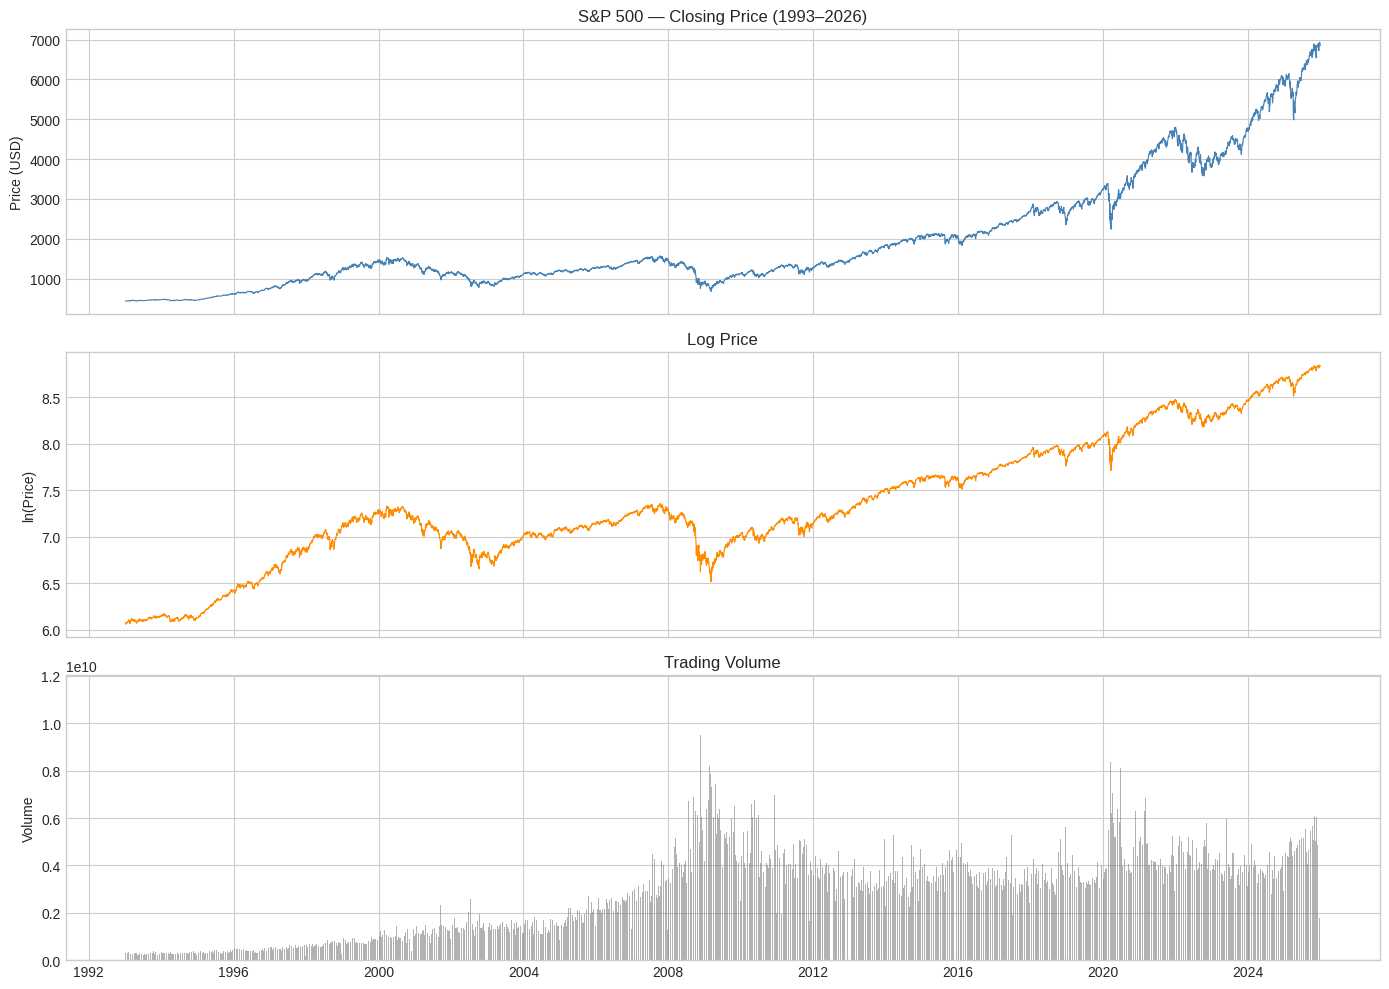

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(data.index, data["Close"], color="steelblue", linewidth=0.8)
axes[0].set_title("S&P 500 — Closing Price (1993–2026)")
axes[0].set_ylabel("Price (USD)")

axes[1].plot(data.index, np.log(data["Close"]), color="darkorange", linewidth=0.8)
axes[1].set_title("Log Price")
axes[1].set_ylabel("ln(Price)")

axes[2].bar(data.index, data["Volume"], color="grey", width=1, alpha=0.6)
axes[2].set_title("Trading Volume")
axes[2].set_ylabel("Volume")

plt.tight_layout()
plt.savefig("gspc_price_volume.png", dpi=150)
plt.show()

## Return Computation

In [5]:
# Simple and log returns
data["Simple_Return"]   = data["Close"].pct_change()
data["Log_Return"]      = np.log(data["Close"] / data["Close"].shift(1))

# Higher-frequency compounding: weekly & monthly log returns
data["Log_Return_5d"]   = np.log(data["Close"] / data["Close"].shift(5))
data["Log_Return_21d"]  = np.log(data["Close"] / data["Close"].shift(21))

# Absolute and squared returns (volatility proxies)
data["Abs_Return"]      = data["Log_Return"].abs()
data["Sq_Return"]       = data["Log_Return"] ** 2

returns = data["Log_Return"].dropna()
print(f"Total trading days : {len(data)}")
print(f"Return observations: {len(returns)}")
print(f"\nFirst 5 log returns:\n{returns.head()}")

Total trading days : 8307
Return observations: 8306

First 5 log returns:
Date
1993-01-05   -0.002392
1993-01-06    0.000414
1993-01-07   -0.008760
1993-01-08   -0.003908
1993-01-11    0.004419
Name: Log_Return, dtype: float64


## Descriptive Statistics

In [6]:
desc = returns.describe()
skewness  = skew(returns)
kurt_exc  = kurtosis(returns)          # fisher excess kurtosis
jb_stat, jb_p = jarque_bera(returns)

print("=" * 48)
print("      Descriptive Statistics — Log Returns")
print("=" * 48)
print(desc.to_string())
print(f"\nSkewness          : {skewness:.6f}")
print(f"Excess Kurtosis   : {kurt_exc:.6f}")
print(f"Jarque-Bera stat  : {jb_stat:.4f}")
print(f"Jarque-Bera p-val : {jb_p:.6e}")
print("=" * 48)

# Annualised statistics
mu_ann  = returns.mean() * 252
std_ann = returns.std()  * np.sqrt(252)
sharpe  = mu_ann / std_ann
print(f"\nAnnualised Mean   : {mu_ann:.4%}")
print(f"Annualised Std    : {std_ann:.4%}")
print(f"Sharpe (rf=0)     : {sharpe:.4f}")

      Descriptive Statistics — Log Returns
count   8306.000000
mean       0.000332
std        0.011612
min       -0.127652
25%       -0.004440
50%        0.000643
75%        0.005733
max        0.109572

Skewness          : -0.375131
Excess Kurtosis   : 10.874947
Jarque-Bera stat  : 41124.1703
Jarque-Bera p-val : 0.000000e+00

Annualised Mean   : 8.3589%
Annualised Std    : 18.4336%
Sharpe (rf=0)     : 0.4535


## Return Distribution Analysis

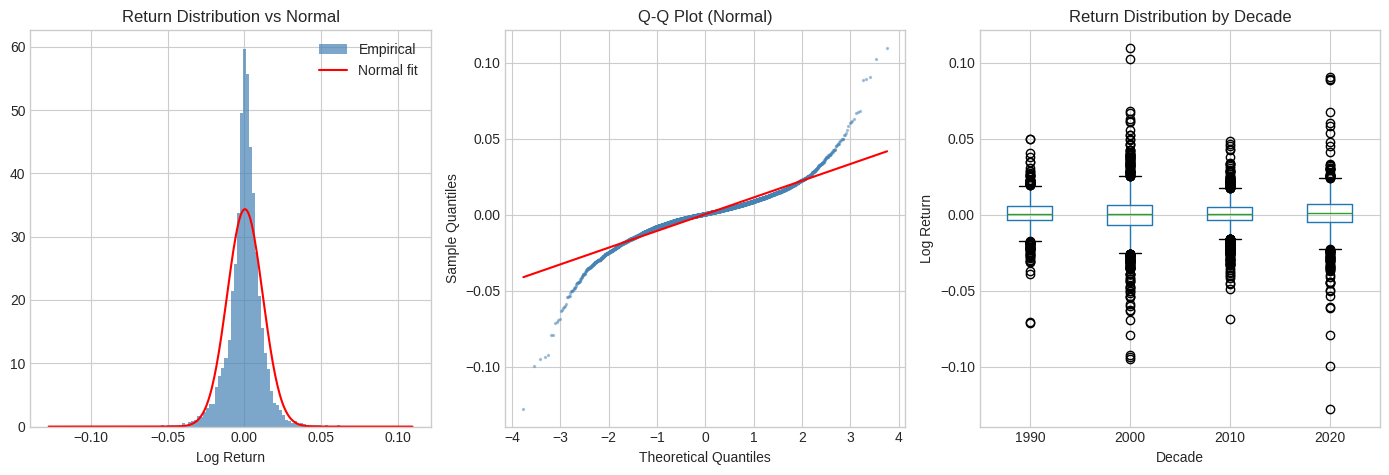

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Histogram with normal overlay
x_range = np.linspace(returns.min(), returns.max(), 300)
axes[0].hist(returns, bins=120, density=True, color="steelblue",
             alpha=0.7, edgecolor="none", label="Empirical")
axes[0].plot(x_range, norm.pdf(x_range, returns.mean(), returns.std()),
             "r-", linewidth=1.5, label="Normal fit")
axes[0].set_title("Return Distribution vs Normal")
axes[0].set_xlabel("Log Return")
axes[0].legend()

# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(returns, dist="norm")
axes[1].scatter(osm, osr, s=2, color="steelblue", alpha=0.4)
axes[1].plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5)
axes[1].set_title("Q-Q Plot (Normal)")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")

# Box plot by decade
data_r = data["Log_Return"].dropna().to_frame()
data_r["Decade"] = (data_r.index.year // 10) * 10
data_r.boxplot(column="Log_Return", by="Decade", ax=axes[2])
axes[2].set_title("Return Distribution by Decade")
axes[2].set_xlabel("Decade")
axes[2].set_ylabel("Log Return")
plt.suptitle("")

plt.tight_layout()
plt.savefig("gspc_distributions.png", dpi=150)
plt.show()

## Stationarity Tests

In [9]:
def run_adf(series, name="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n{'─'*50}")
    print(f"ADF Test — {name}")
    print(f"{'─'*50}")
    print(f"  Test Statistic : {result[0]:.6f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Lags Used      : {result[2]}")
    for k, v in result[4].items():
        print(f"  Critical ({k}) : {v:.6f}")
    print(f"  {'REJECT H0: Stationary' if result[1] < 0.05 else 'FAIL TO REJECT H0: Non-Stationary'}")

def run_kpss(series, name="Series"):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\n{'─'*50}")
    print(f"KPSS Test — {name}")
    print(f"{'─'*50}")
    print(f"  Test Statistic : {result[0]:.6f}")
    print(f"  p-value        : {result[1]:.6f}")
    for k, v in result[3].items():
        print(f"  Critical ({k}) : {v:.6f}")
    print(f"  {'REJECT H0: Non-Stationary' if result[1] < 0.05 else 'FAIL TO REJECT H0: Stationary'}")

run_adf(data["Close"],      "Close Price")
run_adf(data["Log_Return"], "Log Returns")
run_kpss(data["Close"],     "Close Price")
run_kpss(data["Log_Return"],"Log Returns")


──────────────────────────────────────────────────
ADF Test — Close Price
──────────────────────────────────────────────────
  Test Statistic : 3.139072
  p-value        : 1.000000
  Lags Used      : 28
  Critical (1%) : -3.431140
  Critical (5%) : -2.861889
  Critical (10%) : -2.566956
  FAIL TO REJECT H0: Non-Stationary

──────────────────────────────────────────────────
ADF Test — Log Returns
──────────────────────────────────────────────────
  Test Statistic : -16.734109
  p-value        : 0.000000
  Lags Used      : 33
  Critical (1%) : -3.431141
  Critical (5%) : -2.861889
  Critical (10%) : -2.566956
  REJECT H0: Stationary

──────────────────────────────────────────────────
KPSS Test — Close Price
──────────────────────────────────────────────────
  Test Statistic : 11.064183
  p-value        : 0.010000
  Critical (10%) : 0.347000
  Critical (5%) : 0.463000
  Critical (2.5%) : 0.574000
  Critical (1%) : 0.739000
  REJECT H0: Non-Stationary

────────────────────────────────────

## Autocorrelation Structure

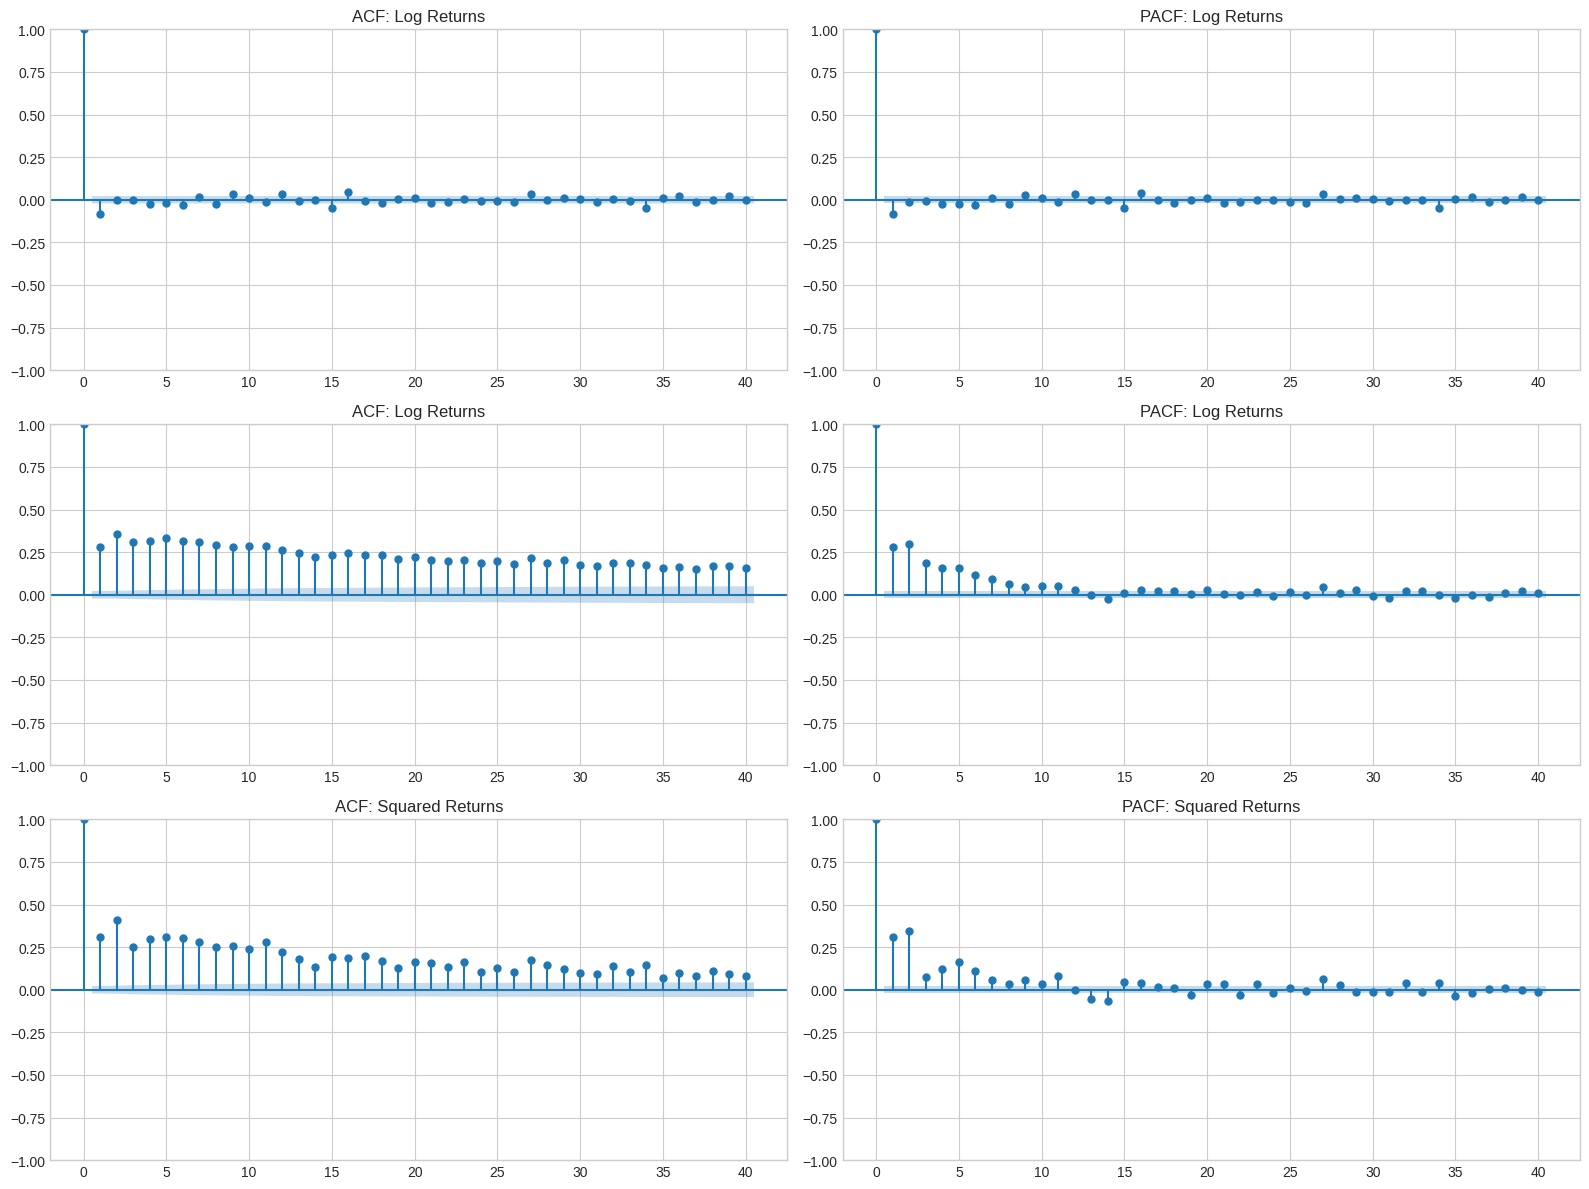

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

lags = 40

plot_acf(returns,             lags=lags, ax=axes[0, 0], title="ACF: Log Returns")
plot_pacf(returns,            lags=lags, ax=axes[0, 1], title="PACF: Log Returns")
plot_acf(returns.abs(),       lags=lags, ax=axes[1, 0], title="ACF: Log Returns")
plot_pacf(returns.abs(),      lags=lags, ax=axes[1, 1], title="PACF: Log Returns")
plot_acf(returns ** 2,        lags=lags, ax=axes[2, 0], title="ACF: Squared Returns")
plot_pacf(returns ** 2,       lags=lags, ax=axes[2, 1], title="PACF: Squared Returns")

plt.tight_layout()
plt.savefig("gspc_autocorrelation.png", dpi=150)
plt.show()

## Rolling Statistics & Regime Detection

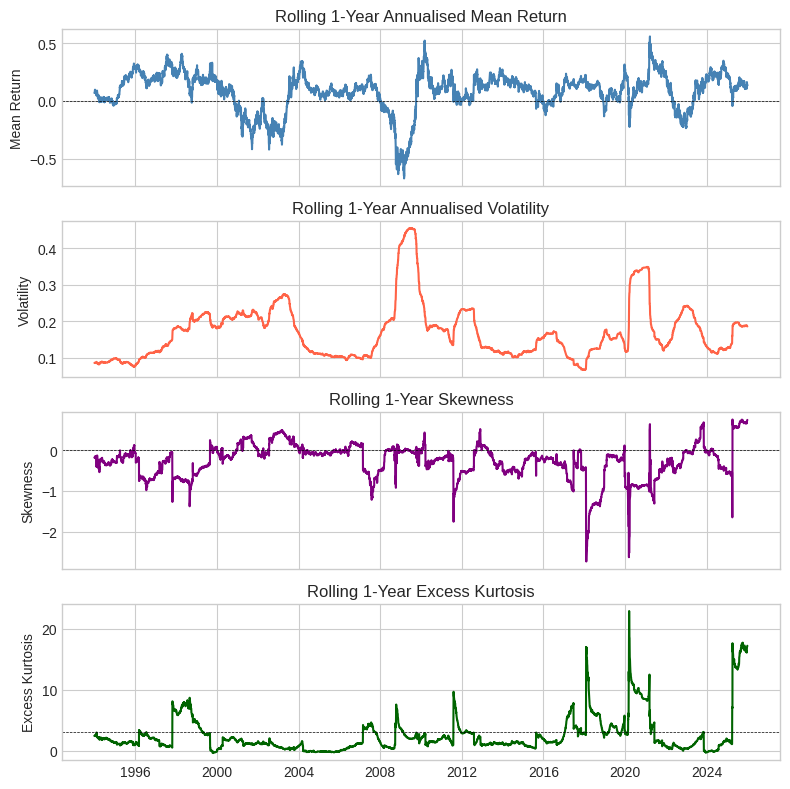

In [13]:
roll_252 = returns.rolling(252)

data["Roll_Mean_252"]   = roll_252.mean()
data["Roll_Std_252"]    = roll_252.std()
data["Roll_Sharpe_252"] = (data["Roll_Mean_252"] * 252) / (data["Roll_Std_252"] * np.sqrt(252))
data["Roll_Skew_252"]   = roll_252.apply(skew)
data["Roll_Kurt_252"]   = roll_252.apply(kurtosis)

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

axes[0].plot(data.index, data["Roll_Mean_252"] * 252, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Rolling 1-Year Annualised Mean Return")
axes[0].set_ylabel("Mean Return")

axes[1].plot(data.index, data["Roll_Std_252"] * np.sqrt(252), color="tomato")
axes[1].set_title("Rolling 1-Year Annualised Volatility")
axes[1].set_ylabel("Volatility")

axes[2].plot(data.index, data["Roll_Skew_252"], color="purple")
axes[2].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[2].set_title("Rolling 1-Year Skewness")
axes[2].set_ylabel("Skewness")

axes[3].plot(data.index, data["Roll_Kurt_252"], color="darkgreen")
axes[3].axhline(3, color="black", linewidth=0.5, linestyle="--")
axes[3].set_title("Rolling 1-Year Excess Kurtosis")
axes[3].set_ylabel("Excess Kurtosis")

plt.tight_layout()
plt.savefig("gspc_rolling_stats.png", dpi=150)
plt.show()

## Volatility Clustering & EWMA

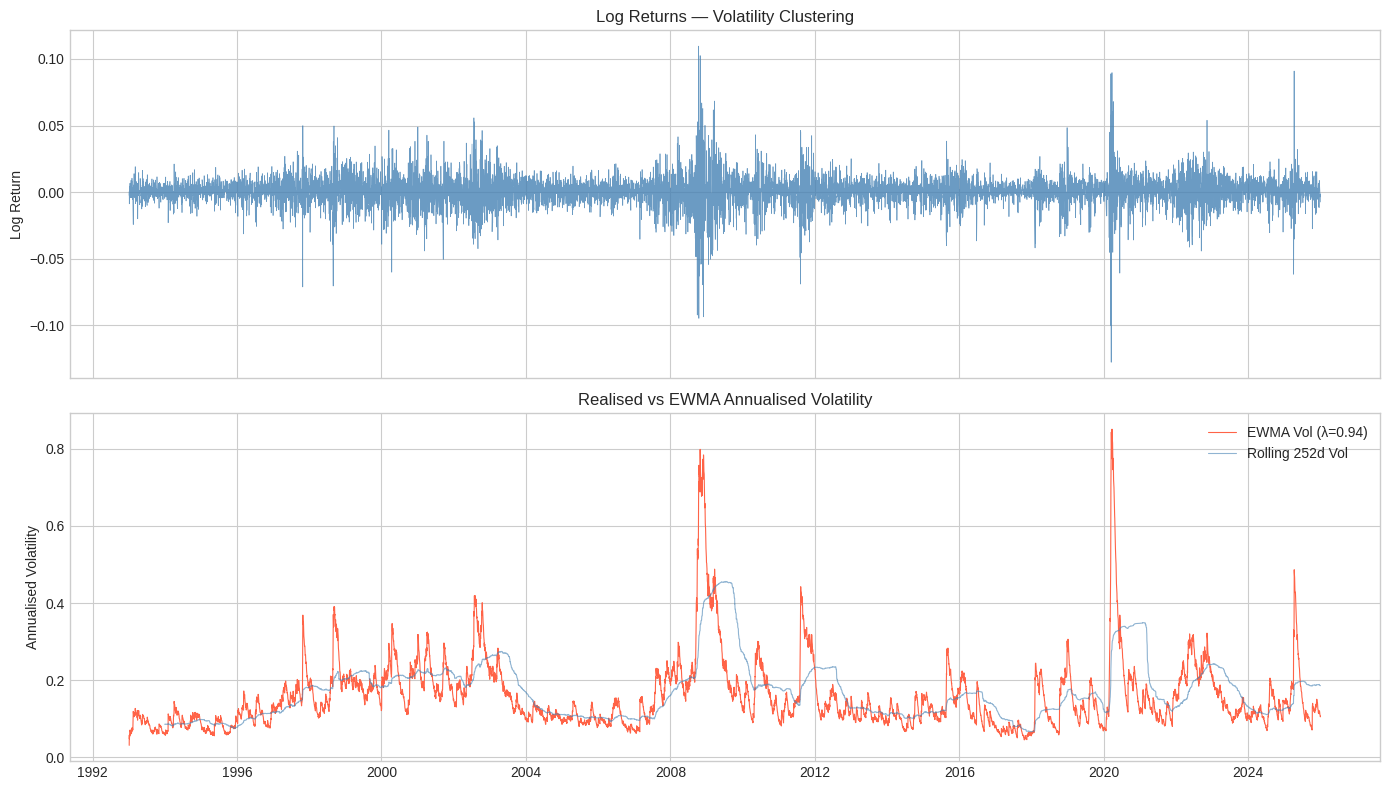

In [14]:
# EWMA volatility (RiskMetrics λ=0.94)
lam = 0.94
ewma_var = returns.ewm(alpha=1 - lam, adjust=False).var()
data["EWMA_Vol"] = np.sqrt(ewma_var * 252)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, data["Log_Return"], color="steelblue",
             linewidth=0.5, alpha=0.8, label="Log Return")
axes[0].set_title("Log Returns — Volatility Clustering")
axes[0].set_ylabel("Log Return")

axes[1].plot(data.index, data["EWMA_Vol"], color="tomato",
             linewidth=0.8, label=f"EWMA Vol (λ={lam})")
axes[1].plot(data.index, data["Roll_Std_252"] * np.sqrt(252),
             color="steelblue", linewidth=0.8, alpha=0.6, label="Rolling 252d Vol")
axes[1].set_title("Realised vs EWMA Annualised Volatility")
axes[1].set_ylabel("Annualised Volatility")
axes[1].legend()

plt.tight_layout()
plt.savefig("gspc_volatility.png", dpi=150)
plt.show()

## Drawdown Analysis

Maximum Drawdown   : -64.33%
Date of Max DD     : 2009-03-09
Recovery Date      : 2014-11-24


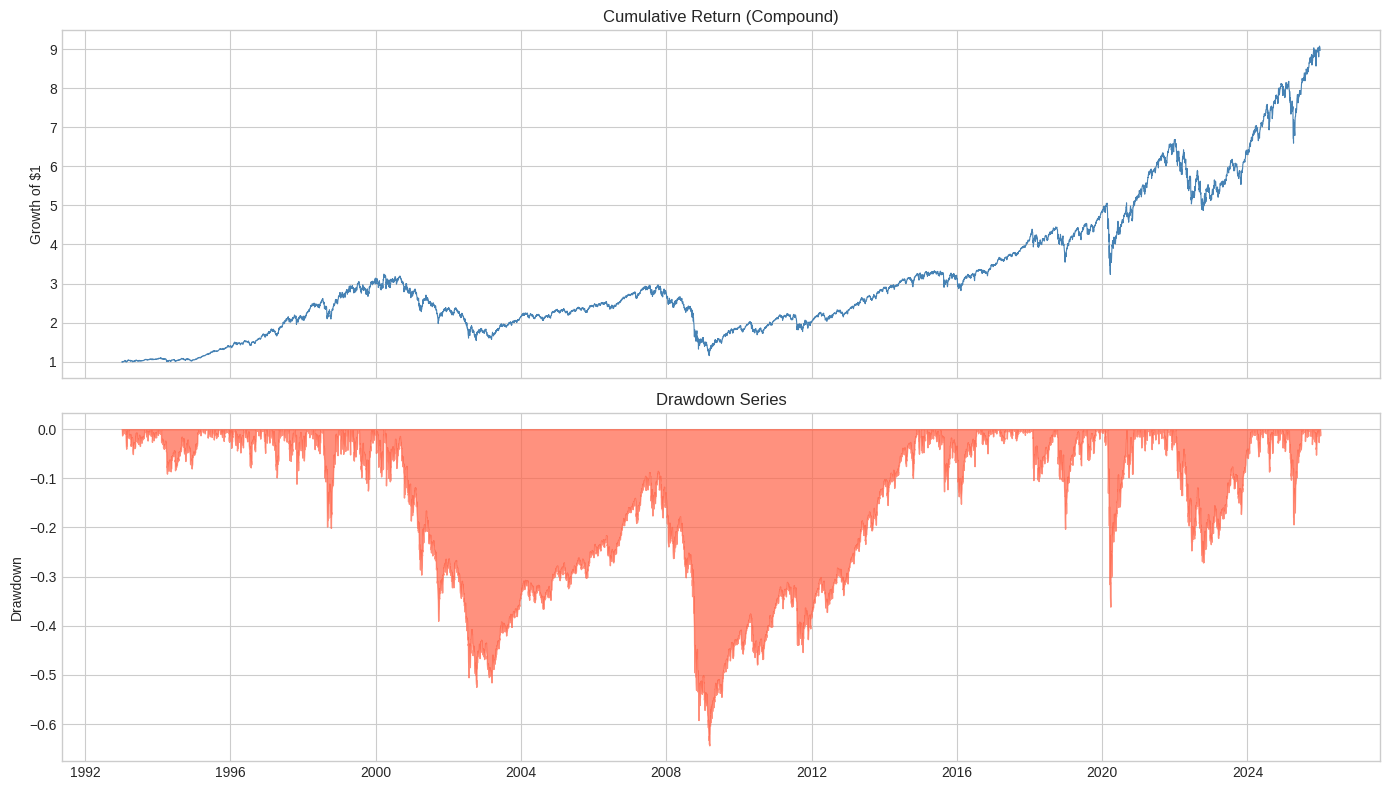

In [15]:
cum_ret  = (1 + data["Log_Return"]).cumprod()
roll_max = cum_ret.cummax()
drawdown = (cum_ret - roll_max) / roll_max

max_dd       = drawdown.min()
max_dd_date  = drawdown.idxmin()
recovery_ser = cum_ret[max_dd_date:]
recovered    = recovery_ser[recovery_ser >= roll_max[max_dd_date]]
recovery_date = recovered.index[0] if not recovered.empty else None

print(f"Maximum Drawdown   : {max_dd:.2%}")
print(f"Date of Max DD     : {max_dd_date.date()}")
print(f"Recovery Date      : {recovery_date.date() if recovery_date else 'Not Recovered'}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, cum_ret, color="steelblue", linewidth=0.8)
axes[0].set_title("Cumulative Return (Compound)")
axes[0].set_ylabel("Growth of $1")

axes[1].fill_between(data.index, drawdown, 0, color="tomato", alpha=0.7)
axes[1].set_title("Drawdown Series")
axes[1].set_ylabel("Drawdown")

plt.tight_layout()
plt.savefig("gspc_drawdown.png", dpi=150)
plt.show()

## Value-at-Risk & Expected Shortfall

In [16]:
confidence_levels = [0.90, 0.95, 0.99]

print("=" * 55)
print("   VaR & Expected Shortfall (1-Day, Log Returns)")
print("=" * 55)
print(f"{'Level':<10} {'Historical VaR':>16} {'Normal VaR':>12} {'ES (CVaR)':>12}")
print("-" * 55)

for cl in confidence_levels:
    alpha       = 1 - cl
    var_hist    = returns.quantile(alpha)
    var_norm    = norm.ppf(alpha, returns.mean(), returns.std())
    es_hist     = returns[returns <= var_hist].mean()

    print(f"{cl:.0%}{'':>5} {var_hist:>14.4%}   {var_norm:>10.4%}   {es_hist:>10.4%}")

print("=" * 55)

# VaR exceedances
var_99 = returns.quantile(0.01)
exceedances = (returns < var_99).sum()
print(f"\n99% VaR Exceedances: {exceedances} ({exceedances/len(returns):.2%} of obs)")

   VaR & Expected Shortfall (1-Day, Log Returns)
Level        Historical VaR   Normal VaR    ES (CVaR)
-------------------------------------------------------
90%            -1.1880%     -1.4550%     -2.1386%
95%            -1.7859%     -1.8768%     -2.8170%
99%            -3.2780%     -2.6682%     -4.7976%

99% VaR Exceedances: 84 (1.01% of obs)


## Tail Risk: Extreme Value Analysis

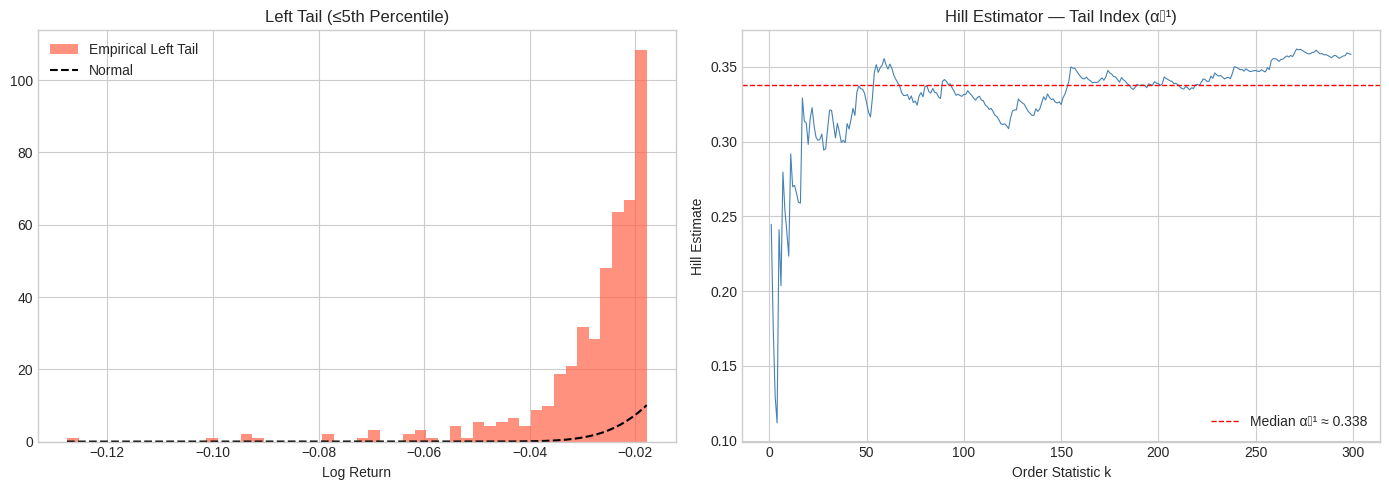

Estimated Tail Index (1/α) ≈ 0.3376
Implied α (tail exponent)  ≈ 2.9624


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left tail empirical vs normal
tail_cutoff = returns.quantile(0.05)
left_tail   = returns[returns <= tail_cutoff]

axes[0].hist(left_tail, bins=50, density=True, color="tomato", alpha=0.7, label="Empirical Left Tail")
x_tail = np.linspace(left_tail.min(), tail_cutoff, 200)
axes[0].plot(x_tail, norm.pdf(x_tail, returns.mean(), returns.std()),
             "k--", linewidth=1.5, label="Normal")
axes[0].set_title("Left Tail (≤5th Percentile)")
axes[0].set_xlabel("Log Return")
axes[0].legend()

# Hill plot for tail index estimation
sorted_neg  = np.sort(-returns[returns < 0])[::-1]
k_vals      = np.arange(1, min(300, len(sorted_neg)))
hill_index  = [np.mean(np.log(sorted_neg[:k])) - np.log(sorted_neg[k])
               for k in k_vals if k < len(sorted_neg)]

axes[1].plot(k_vals[:len(hill_index)], hill_index, color="steelblue", linewidth=0.8)
axes[1].axhline(np.median(hill_index), color="red", linestyle="--",
                linewidth=1, label=f"Median α⁻¹ ≈ {np.median(hill_index):.3f}")
axes[1].set_title("Hill Estimator — Tail Index (α⁻¹)")
axes[1].set_xlabel("Order Statistic k")
axes[1].set_ylabel("Hill Estimate")
axes[1].legend()

plt.tight_layout()
plt.savefig("gspc_tail_risk.png", dpi=150)
plt.show()

print(f"Estimated Tail Index (1/α) ≈ {np.median(hill_index):.4f}")
print(f"Implied α (tail exponent)  ≈ {1/np.median(hill_index):.4f}")

## Time Series Decomposition

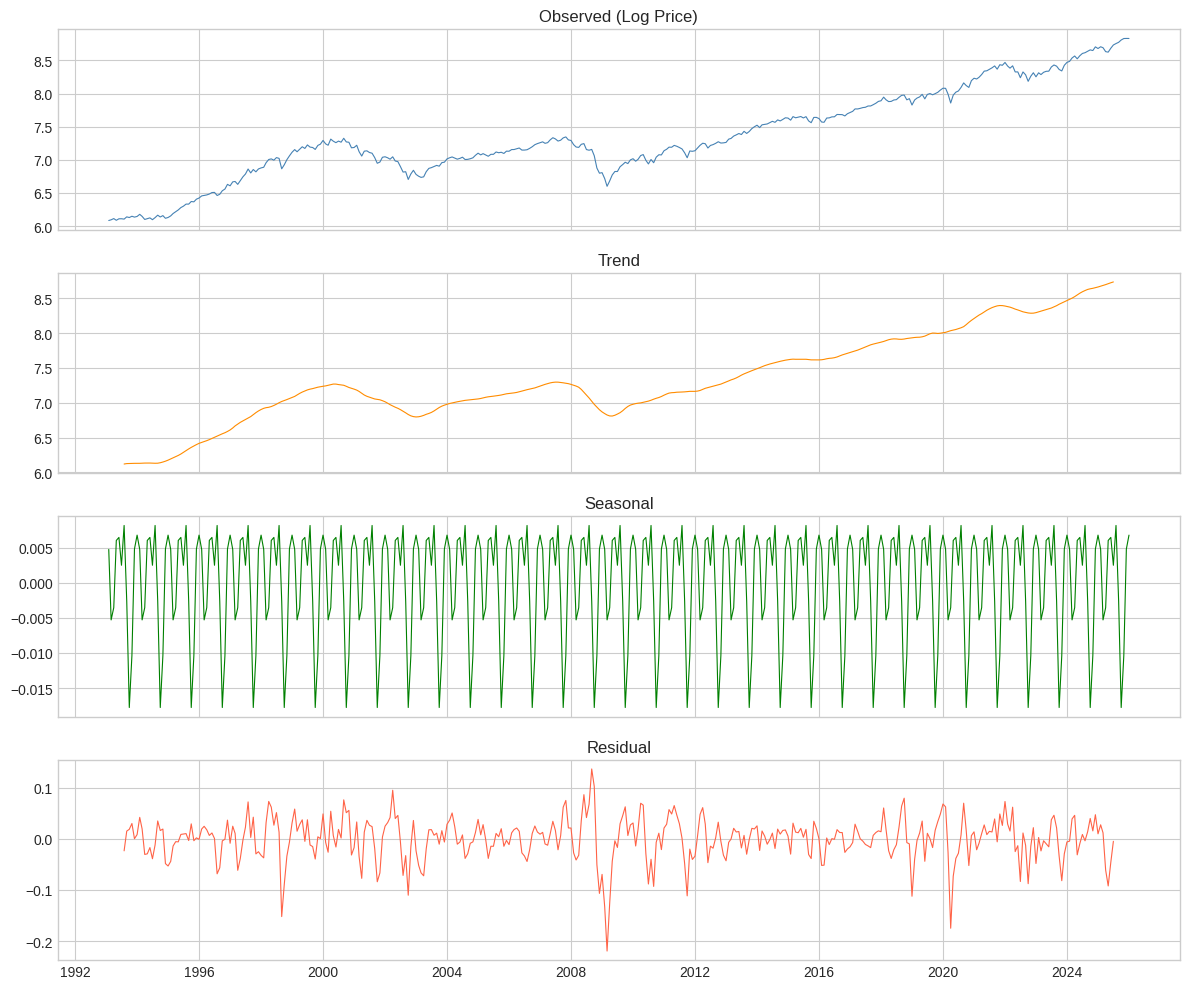

In [19]:
# Resample to monthly for decomposition readability
monthly_close = data["Close"].resample("ME").last()

decomp = seasonal_decompose(np.log(monthly_close), model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
components = {
    "Observed (Log Price)": decomp.observed,
    "Trend":                decomp.trend,
    "Seasonal":             decomp.seasonal,
    "Residual":             decomp.resid,
}
colors = ["steelblue", "darkorange", "green", "tomato"]

for ax, (title, comp), color in zip(axes, components.items(), colors):
    ax.plot(comp, color=color, linewidth=0.8)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("gspc_decomposition.png", dpi=150)
plt.show()

## Correlation Heatmap of Derived Features

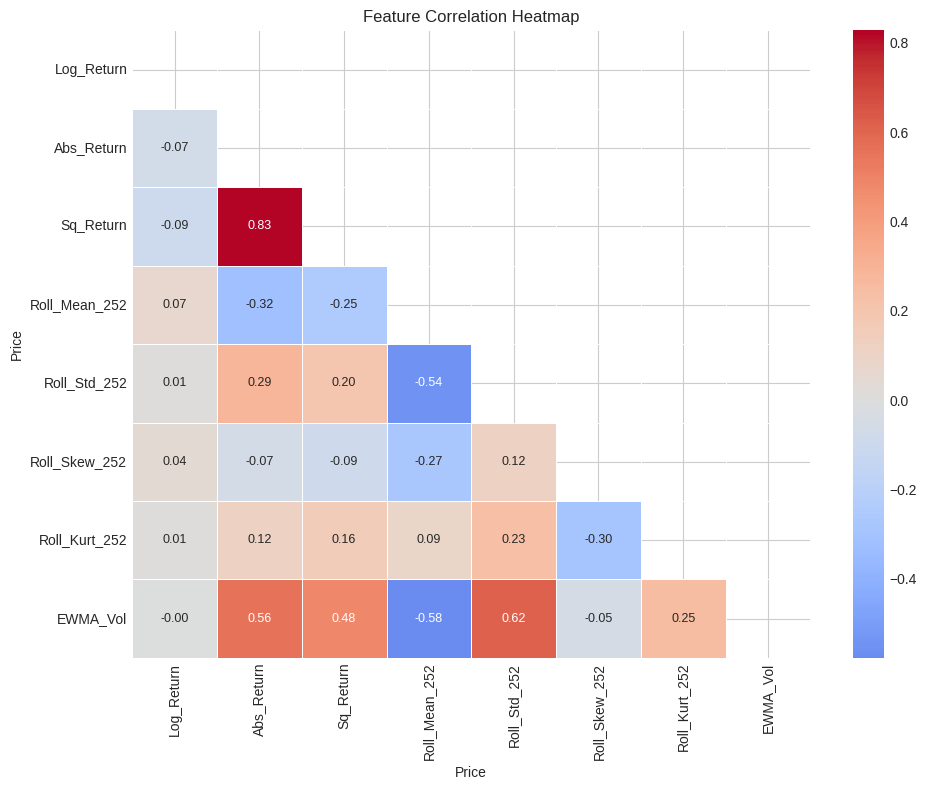

In [20]:
feature_cols = [
    "Log_Return", "Abs_Return", "Sq_Return",
    "Roll_Mean_252", "Roll_Std_252", "Roll_Skew_252",
    "Roll_Kurt_252", "EWMA_Vol"
]

corr_matrix = data[feature_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("gspc_correlation_heatmap.png", dpi=150)
plt.show()

##

##

##

##